# Combining Mean and Volatility Models

Notebook 08 modeled the conditional mean, and Notebook 09 modeled conditional variance. I now combine them: past observations affect the expected value, while past squared innovations and variances affect uncertainty around it.

I define the combined model, estimate and diagnose it using the earlier tools, then forecast its mean and variance. One simulated AR(1)–GARCH(1,1) example keeps the argument concrete. Notebook 11 applies the workflow to financial data.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from finstats.timeseries.diagnostics import acf, ljung_box
from finstats.timeseries.forecasting import forecast_mse, forecast_rmse, forecast_mae
from arch import arch_model
from finstats.timeseries.diagnostics import mcleod_li, standardized_residuals
from finstats.timeseries.volatility import (
    simulate_arch1, arch1_unconditional_variance, simulate_garch11,
    garch11_unconditional_variance, garch11_variance_path, garch11_forecast,
)
from finstats.timeseries.ar import ar1_forecast
from finstats.timeseries.composite import simulate_ar1_garch11
from finstats.risk import gaussian_var, gaussian_es, student_t_var, student_t_es
from arch.univariate import Normal, StudentsT

def stem_dependence(ax, values, title, nobs, ylabel="Correlation"):
    lags = np.arange(len(values))
    ax.vlines(lags, 0, values, color="C0", linewidth=1.2)
    ax.scatter(lags, values, s=10, color="C0")
    ax.axhline(0, color="0.6", linewidth=.8)
    # Pointwise reference limits under an IID white-noise null, excluding lag zero.
    bound = stats.norm.ppf(.975)/np.sqrt(nobs)
    ax.hlines([bound,-bound], .5, lags[-1]+.5, color="0.35", linestyle="--",
              linewidth=.9, label="Approx. 95% white-noise bounds")
    ax.set(xlabel="Lag", ylabel=ylabel, title=title)


## 1. Combined Models

### Model

**Definition: combined mean–variance model.** A stationary return or a justified differenced series $X_t$ has an ARMA conditional-mean equation and a conditional-variance equation. For an ARMA(p,q) mean with GARCH(1,1) variance,
$$X_t-\mu=\sum_{j=1}^p\phi_j(X_{t-j}-\mu)+a_t+\sum_{k=1}^q\theta_k a_{t-k},$$
$$a_t=\sigma_t\nu_t,\qquad\sigma_t^2=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2.$$
Standardized innovations $\nu_t$ are IID, independent of the past, with mean zero and variance one. Gaussianity is an additional density assumption. The conditional mean follows the linear-model logic of Notebook 08, and the variance follows Notebook 09. If differencing is required, these equations apply to the differenced series, rather than a stationary original level.

### AR(1)–GARCH(1,1)

#### Model

The worked model is
$$X_t-\mu=\phi(X_{t-1}-\mu)+a_t,\qquad
 a_t=\sigma_t\nu_t,\qquad \sigma_t^2=\omega+\alpha a_{t-1}^2+\beta\sigma_{t-1}^2.$$

#### Population Moments

The conditional mean and variance are
$$m_t=\mu+\phi(X_{t-1}-\mu),\qquad
E[X_t\mid\mathcal F_{t-1}]=m_t,\qquad
\operatorname{Var}(X_t\mid\mathcal F_{t-1})=\sigma_t^2.$$
For a finite-variance stationary solution,
$$E[X_t]=\mu,\qquad\operatorname{Var}(a_t)=\frac\omega{1-\alpha-\beta},\qquad
\operatorname{Var}(X_t)=\frac{\operatorname{Var}(a_t)}{1-\phi^2}.$$
The innovations are serially uncorrelated even though their conditional variances depend on the past. Return variance includes both innovation uncertainty and its propagation through the AR equation.

#### Positivity and Stationarity Conditions

Require $|\phi|<1$, $\omega>0$, $\alpha,\beta\ge0$ and $\alpha+\beta<1$ for the worked finite-second-moment stationary model. General ARMA mean conditions are those of Notebook 08, and general ARCH/GARCH conditions are those of Notebook 09. Finite fourth moments remain a separate requirement for covariance-based squared-residual diagnostics.

### Simulation Setup

For illustration, I use $\mu=0$, $\phi=.7$, $\omega=.05$, $\alpha=.05$, $\beta=.9$ and IID standardized Student-t innovations with five degrees of freedom ($\nu_t=\sqrt{3/5}\,T_t$, $T_t\sim t_5$). I simulate 1500 observations with seed 1212 and burn-in to approximate stationary initialization. The first 1200 observations are used for estimation; the final 300 are reserved out of sample. This deliberate heavy-tailed simulation makes the innovation-distribution comparison visible; it does not assume Student-t is always preferable in financial data.

In [2]:
combined_values, combined_shocks, combined_variances = simulate_ar1_garch11(
    .7, .05, .05, .9, 1500, rng=1212, df=5)
true_conditional_mean = combined_values-combined_shocks
combined_train, combined_test = combined_values[:1200], combined_values[1200:]

## 2. Estimation, Diagnostics and Evaluation

Use the likelihood framework from Notebooks 08 and 09. The following six steps identify and fit the mean, assess remaining dependence, jointly estimate mean and variance, check the residuals and density, and compare candidates. All steps use only the estimation observations.

### 1. Identify and Fit the Linear Model

Following Notebook 08, examine ACF/PACF before fitting. A decaying ACF with a PACF concentrated at the first lag suggests an AR(1) candidate. Finite-sample patterns are approximate, rather than proof of the generating order. No differencing is needed for this stationary simulated process.

#### Example: ACF/PACF Identification

The first figure shows the estimation-sample ACF and PACF. I use AR(1) as the worked mean specification and fit it using Gaussian state-space MLE.

The initial Gaussian mean fit uses a working likelihood; Gaussianity is not the true innovation assumption in this simulation.

Dashed lines show the approximate pointwise 95% white-noise reference bounds $\pm1.96/\sqrt{n}$, using the number of observations in each plotted sample. They are centered on zero, not on the estimated correlations or population curve. Exceeding a bound flags possible dependence; these are not simultaneous bounds, and fitted-residual and squared-series interpretations remain approximate and require suitable moment assumptions.

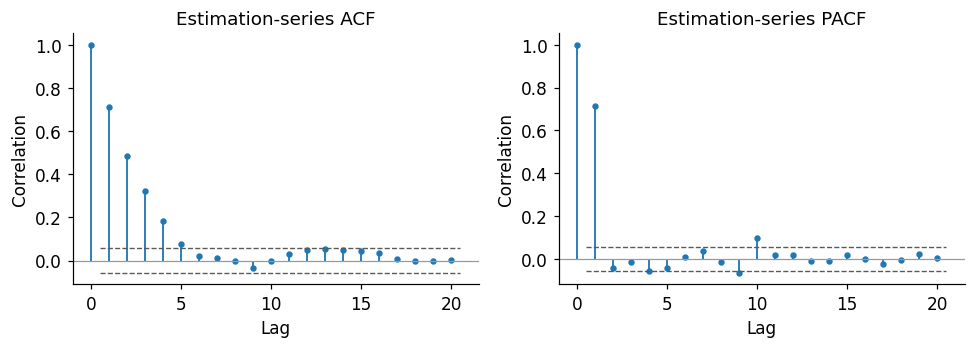

In [3]:
fig, axes = plt.subplots(1,2,figsize=(9,3.3),sharex=True)
stem_dependence(axes[0],acf(combined_train,20,adjusted=False),"Estimation-series ACF", len(combined_train))
stem_dependence(axes[1],pacf(combined_train,nlags=20,method="ywm"),"Estimation-series PACF", len(combined_train))
fig.tight_layout();plt.show()
mean_only_fit = ARIMA(combined_train, order=(1,0,0), trend="c").fit()
assert mean_only_fit.mle_retvals.get("converged", True)
mean_only_residuals = np.asarray(mean_only_fit.resid)[1:]

### 2. Check Residuals and ARCH Effects

Check whether mean-model residuals retain serial correlation using the residual ACF and Ljung–Box test from Notebook 08. Then inspect their squares and apply the McLeod–Li test from Notebook 09. Residuals may have little linear correlation while their magnitudes remain dependent. White noise does not mean IID or constant conditional variance.

I compute both tests before joint estimation. Their ACFs are shown alongside the final model's diagnostics below, making the before-and-after comparison visible in one figure. Squared-residual patterns motivate a variance equation rather than mechanically fixing its exact order.

In [4]:
mean_level_check = ljung_box(mean_only_residuals,20,model_df=1)
mean_square_check = mcleod_li(mean_only_residuals,20)
print(f"Mean-model residual Ljung–Box p-value: {mean_level_check['p_value']:.4f}")
print(f"Squared-residual McLeod–Li p-value: {mean_square_check['p_value']:.4g}")

Mean-model residual Ljung–Box p-value: 0.0429
Squared-residual McLeod–Li p-value: 0.003205


### 3. Fit the Mean and Variance Jointly

Joint MLE estimates mean and variance parameters together. A GARCH fit to fixed AR residuals would be a two-stage procedure. I fit AR(1)–GARCH(1,1) with Gaussian innovations and a standardized Student-t alternative, using the same estimation observations and one-observation hold-back.

The mature `arch` estimator supports an AR mean with GARCH variance, but not a general MA or integrated mean equation. The worked example therefore uses AR(1). Initial values and convergence matter, as in Notebook 09. The Gaussian fit remains the benchmark for the later forecast, while the Student-t candidate is assessed below.

The compact table reports Gaussian joint estimates and approximate standard errors.

In [5]:
combined_fit = arch_model(combined_train, mean="AR", lags=1, vol="GARCH", p=1, q=1,
                          dist="normal", hold_back=1, rescale=False).fit(disp="off", update_freq=0)
if combined_fit.convergence_flag != 0:
    raise RuntimeError("Combined-model fit did not converge")
display(pd.DataFrame({"Estimate": combined_fit.params, "Standard error": combined_fit.std_err}).round(4))
combined_valid = np.isfinite(combined_fit.resid)&np.isfinite(combined_fit.conditional_volatility)
combined_standardized = standardized_residuals(np.asarray(combined_fit.resid)[combined_valid],
                                                np.asarray(combined_fit.conditional_volatility)[combined_valid])
student_combined_fit = arch_model(combined_train,mean="AR",lags=1,vol="GARCH",p=1,q=1,
                                  dist="t",hold_back=1,rescale=False).fit(disp="off",update_freq=0)
assert student_combined_fit.convergence_flag == 0
student_valid = np.isfinite(student_combined_fit.resid)&np.isfinite(student_combined_fit.conditional_volatility)
student_standardized = standardized_residuals(np.asarray(student_combined_fit.resid)[student_valid],
                                               np.asarray(student_combined_fit.conditional_volatility)[student_valid])
student_df = float(student_combined_fit.params["nu"])
assert student_df > 2

,Estimate,Standard error
Const,0.0034,0.0270
y[1],0.7219,0.0202
omega,0.1218,0.0382
alpha[1],0.0762,0.0260
beta[1],0.7930,0.0497


### 4. Check Joint-Model Residuals

As in Notebook 09, examine standardized residuals and their squares. Ljung–Box assesses remaining linear correlation and McLeod–Li assesses magnitude dependence. Both should show little remaining correlation for an adequate specification. Non-rejection does not prove independence or a correct density.

#### Example: Before and After Joint Estimation

The four-panel figure contrasts mean-only residuals and their squares with Gaussian joint-model standardized residuals and their squares. One compact table reports the corresponding tests and those for the Student-t candidate. Squared-series screening requires finite fourth moments; I omit its nominal p-value if the fitted Student-t degrees of freedom are at most four.

statistic  p_value  df  lags  nobs
Model           Series                                                  
Mean-only       Residuals               30.7627   0.0429  19    20  1199
                Squared residuals       41.5063   0.0032  20    20  1199
Gaussian joint  Standardized            25.6306   0.1408  19    20  1199
                Squared standardized    13.5045   0.8547  20    20  1199
Student-t joint Standardized            25.5119   0.1444  19    20  1199
                Squared standardized    14.0102   0.8300  20    20  1199

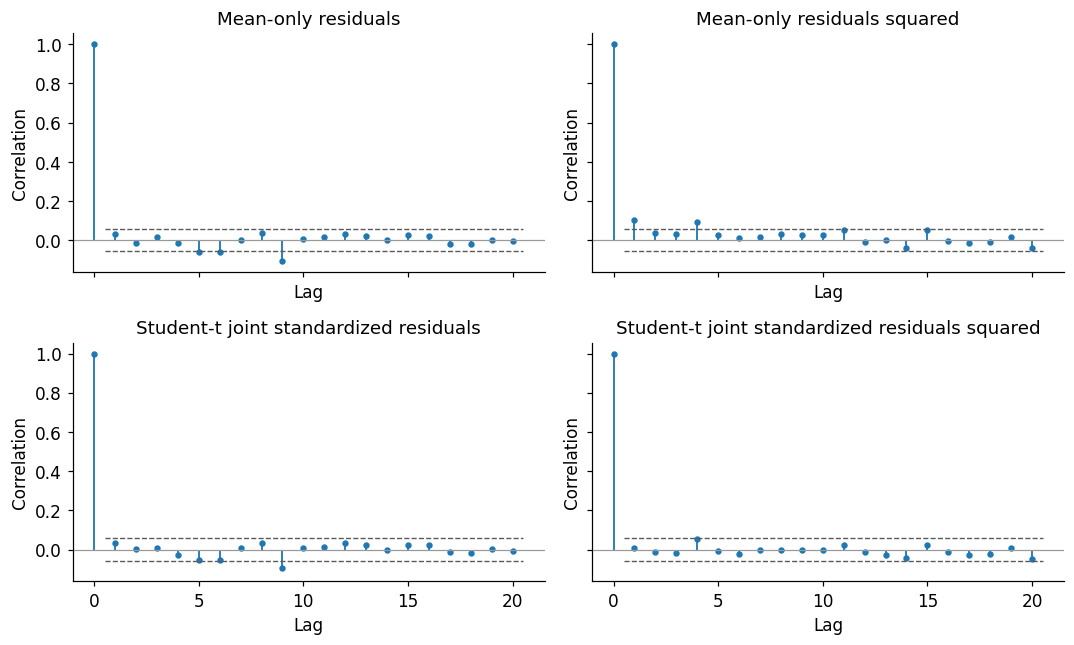

In [6]:
checks = [
    {"Model":"Mean-only", "Series":"Residuals",**mean_level_check},
    {"Model":"Mean-only", "Series":"Squared residuals",**mean_square_check},
]
for label, values, fit in [("Gaussian joint",combined_standardized,combined_fit),
                           ("Student-t joint",student_standardized,student_combined_fit)]:
    squared_check = mcleod_li(values,20)
    if fit.params.get("nu",np.inf) <= 4:
        squared_check["p_value"] = np.nan
    checks.extend([{"Model":label,"Series":"Standardized",**ljung_box(values,20,model_df=1)},
                   {"Model":label,"Series":"Squared standardized",**squared_check}])
display(pd.DataFrame(checks).set_index(["Model","Series"]).round(4))
fig, axes = plt.subplots(2,2,figsize=(10,6),sharex=True,sharey=True)
for row, (label,values) in enumerate([("Mean-only residuals",mean_only_residuals),
                                     ("Student-t joint standardized residuals",student_standardized)]):
    stem_dependence(axes[row,0],acf(values,20,adjusted=False),label,len(values))
    stem_dependence(axes[row,1],acf(values**2,20,adjusted=False),label+" squared",len(values))
fig.tight_layout();plt.show()

### 5. Check the Innovation Distribution

Following Notebook 04, QQ plots compare empirical quantiles with those implied by a candidate density. Here the Gaussian fit's standardized residuals are compared with standard Gaussian quantiles, and the Student-t fit's standardized residuals with unit-variance Student-t quantiles at its fitted degrees of freedom. This compares each candidate's residuals with its own assumption, rather than treating different residual samples as identical.

The figure asks whether systematic tail departures remain. QQ plots guide the density choice but do not definitively select a model. Student-t need not improve this Gaussian-generated example, and finite-sample deviations alone are not evidence of a different DGP.

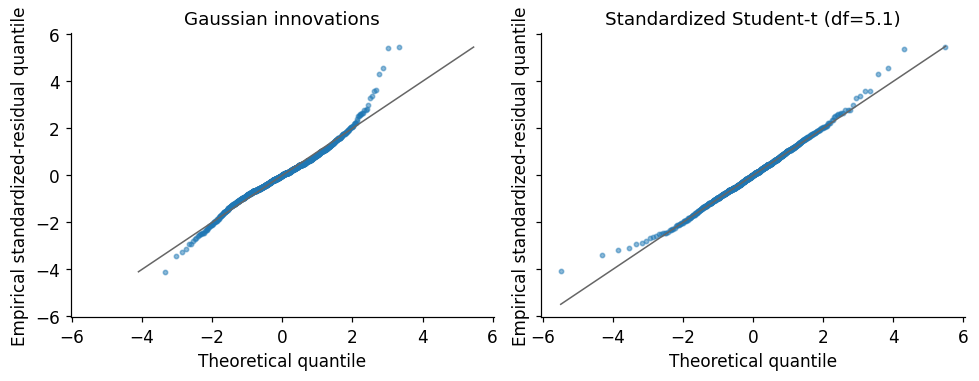

In [7]:
fig, axes = plt.subplots(1,2,figsize=(9,3.6),sharex=True,sharey=True)
for ax, values, label, candidate in [
    (axes[0],combined_standardized,"Gaussian innovations",stats.norm()),
    (axes[1],student_standardized,f"Standardized Student-t (df={student_df:.1f})",
     stats.t(df=student_df,scale=np.sqrt((student_df-2)/student_df)))]:
    ordered = np.sort(values)
    probabilities = (np.arange(1,len(ordered)+1)-.5)/len(ordered)
    theoretical = candidate.ppf(probabilities)
    ax.scatter(theoretical,ordered,s=8,alpha=.5)
    limits = [min(theoretical[0],ordered[0]),max(theoretical[-1],ordered[-1])]
    ax.plot(limits,limits,color="0.4",linewidth=1)
    ax.set(title=label,xlabel="Theoretical quantile",ylabel="Empirical standardized-residual quantile")
fig.tight_layout();plt.show()

The sample was generated with heavy-tailed Student-t innovations. In the tails, the Gaussian reference understates their dispersion, while the fitted Student-t reference should follow the empirical quantiles more closely. QQ plots diagnose the density assumption; they do not establish that residuals are independent.

### 6. Compare Models Using AIC and BIC

Use the same criteria as Notebooks 08 and 09, comparing models fitted to the same observations with comparable likelihood treatment. Their complexity penalties apply to the mean parameters, variance parameters and any estimated density parameters together.

#### Example: Comparing Variance Specifications

I compare AR(1) with constant variance, AR(1)–ARCH(1) and AR(1)–GARCH(1,1). I also include the standardized Student-t AR(1)–GARCH(1,1) alternative. All candidates use the `arch` package, Gaussian or Student-t standardized innovations and a common one-observation hold-back. This keeps the sample and likelihood treatment consistent. The joint GARCH model remains the stated benchmark for forecasting; an information-criterion preference does not guarantee better future predictions.

In [8]:
constant_variance_fit = arch_model(combined_train,mean="AR",lags=1,vol="Constant",
                                   dist="normal",hold_back=1,rescale=False).fit(disp="off",update_freq=0)
combined_arch_fit = arch_model(combined_train,mean="AR",lags=1,vol="ARCH",p=1,
                               dist="normal",hold_back=1,rescale=False).fit(disp="off",update_freq=0)
comparison_rows = []
for label, fit in [("AR(1), constant variance",constant_variance_fit),
                   ("AR(1)–ARCH(1)",combined_arch_fit),("Gaussian AR(1)–GARCH(1,1)",combined_fit),
                   ("Student-t AR(1)–GARCH(1,1)",student_combined_fit)]:
    assert fit.convergence_flag == 0
    assert fit.nobs == combined_fit.nobs
    m = len(fit.params)
    np.testing.assert_allclose(fit.aic,-2*fit.loglikelihood+2*m)
    np.testing.assert_allclose(fit.bic,-2*fit.loglikelihood+m*np.log(fit.nobs))
    comparison_rows.append({"Model":label,"Parameters":m,"Log-likelihood":fit.loglikelihood,
                            "AIC":fit.aic,"BIC":fit.bic})
display(pd.DataFrame(comparison_rows).set_index("Model").round(3))
forecast_candidates = {"Gaussian": combined_fit, "Student-t": student_combined_fit}
forecast_label, forecast_fit = min(forecast_candidates.items(), key=lambda item: item[1].bic)
forecast_valid = np.isfinite(forecast_fit.resid) & np.isfinite(forecast_fit.conditional_volatility)
print("Forecast innovation distribution selected by BIC:", forecast_label)

,Parameters,Log-likelihood,AIC,BIC
Model,,,,
"AR(1), constant variance",3,-1649.505,3305.009,3320.277
AR(1)–ARCH(1),4,-1643.944,3295.888,3316.245
"Gaussian AR(1)–GARCH(1,1)",5,-1631.951,3273.902,3299.348
"Student-t AR(1)–GARCH(1,1)",6,-1586.076,3184.152,3214.688


Forecast innovation distribution selected by BIC: Student-t


Compare AIC and BIC before forecasting. The subsequent forecasts use the lower-BIC innovation distribution among the two joint GARCH specifications, rather than choosing it from the QQ plot alone.

## 3. Forecasting

### Definition

The mean forecast is the conditional expectation of a future observation, as in Notebook 08. The innovation-variance forecast is the expected future conditional variance, as in Notebook 09. Combining the equations requires keeping these targets distinct.

### Conditional Mean Forecasts

Write the fitted AR equation as $X_t=c+\phi X_{t-1}+a_t$, where $c=(1-\phi)\mu$. The one-step forecast is
$$\hat m_{n+1|n}=\hat c+\hat\phi x_n.$$
For h steps, use the AR(1) recursion from Notebook 08:
$$\hat m_{n+h|n}=\hat\mu+\hat\phi^h(x_n-\hat\mu).$$

### Conditional Variance Forecasts

The one-step innovation variance is
$$\hat v_{n+1|n}=\hat\omega+\hat\alpha\hat a_n^2+\hat\beta\hat\sigma_n^2.$$
Longer-horizon innovation variances follow the GARCH recursion of Notebook 09. Future return uncertainty also includes propagation through the AR equation:
$$\operatorname{Var}(X_{n+h}-m_{n+h|n}\mid\mathcal F_n)
=\sum_{k=1}^h\phi^{2(h-k)}E[\sigma_{n+k}^2\mid\mathcal F_n].$$
This population identity uses known parameters; the computations substitute estimates. Innovation forecast variance and return forecast variance coincide at one step, but generally differ afterward. Parameter uncertainty is not included.

### Example: Combined Forecasts

I forecast the first 24 reserved observations without refitting and check the explicit mean and variance recursions against the package. One figure combines the last 150 estimation observations, the expected future path, a 95% prediction band and out-of-sample dots. The question is how realized future observations compare with their predicted values and uncertainty.

The band uses the 2.5th and 97.5th percentiles of 20,000 future histories simulated from the fitted model, with seed 10101. Unlike the course’s MSE-based display, these bands use predictive quantiles. This respects the changing variance and AR propagation, rather than assuming Gaussian multi-step returns. It is a pointwise interval for each future observation, not a confidence interval for the conditional mean or a simultaneous interval for the whole path. Parameters are held fixed at their estimates, so parameter-estimation uncertainty is omitted. The reserved observations are overlaid afterward and do not enter the simulations.

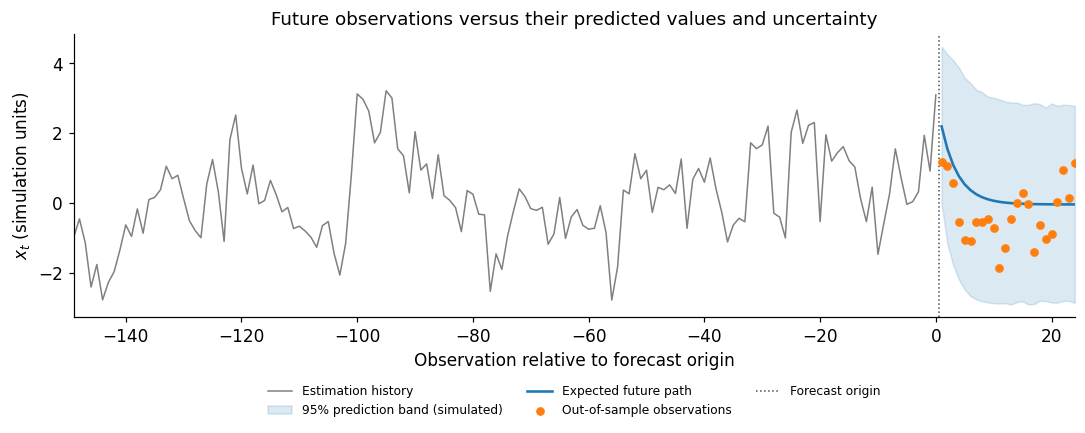

In [9]:
combined_params = forecast_fit.params
phi_hat = float(combined_params.iloc[1])
intercept_hat = float(combined_params["Const"])
if abs(phi_hat) >= 1:
    raise RuntimeError("Worked stationary AR mean fit reached a nonstationary estimate")
combined_mu_hat = intercept_hat/(1-phi_hat)
last_shock = np.asarray(forecast_fit.resid)[forecast_valid][-1]
last_variance = np.asarray(forecast_fit.conditional_volatility)[forecast_valid][-1]**2
conditional_mean_forecast = ar1_forecast(combined_train[-1], phi_hat, combined_mu_hat, 24)
innovation_forecast = garch11_forecast(last_shock, last_variance, combined_params["omega"],
                                      combined_params["alpha[1]"], combined_params["beta[1]"], 24)
return_variance_forecast = np.convolve(innovation_forecast, phi_hat**(2*np.arange(24)))[:24]
combined_prediction = forecast_fit.forecast(horizon=24, reindex=False)
np.testing.assert_allclose(conditional_mean_forecast, combined_prediction.mean.iloc[-1], atol=1e-8)
np.testing.assert_allclose(innovation_forecast, combined_prediction.residual_variance.iloc[-1], atol=1e-8)
np.testing.assert_allclose(return_variance_forecast, combined_prediction.variance.iloc[-1], atol=1e-8)
forecast_rng = (StudentsT(seed=10101).simulate([forecast_fit.params["nu"]])
                if forecast_label == "Student-t" else Normal(seed=10101).simulate([]))
simulated_prediction = forecast_fit.forecast(
    horizon=24,method="simulation",simulations=20000,reindex=False,
    rng=forecast_rng)
future_paths = np.asarray(simulated_prediction.simulations.values)[-1]
assert future_paths.shape == (20000,24)
assert np.all(np.isfinite(future_paths))
lower, upper = np.quantile(future_paths,[.025,.975],axis=0)
assert np.all(lower <= upper)
history_times = np.arange(-149,1)
future_times = np.arange(1,25)
fig, ax = plt.subplots(figsize=(10,4.2))
ax.plot(history_times,combined_train[-150:],color="0.5",linewidth=1,label="Estimation history")
ax.fill_between(future_times,lower,upper,color="C0",alpha=.16,
                label="95% prediction band (simulated)")
ax.plot(future_times,conditional_mean_forecast,color="C0",linewidth=1.7,
        label="Expected future path")
ax.scatter(future_times,combined_test[:24],color="C1",s=22,
           label="Out-of-sample observations",zorder=3)
ax.axvline(.5,color="0.3",linestyle=":",linewidth=1,label="Forecast origin")
ax.set(xlabel="Observation relative to forecast origin",ylabel="$x_t$ (simulation units)",
       title="Future observations versus their predicted values and uncertainty",xlim=(-149,24))
ax.legend(fontsize=8,ncol=3,loc="upper center",bbox_to_anchor=(.5,-.2))
fig.tight_layout();plt.show()


### Forecast Evaluation

Following Notebook 08, I summarize mean-forecast errors against the first 24 out-of-sample observations using ME, RMSE and MAE. These are observation-forecast errors, not errors in estimating volatility. One continuation does not establish general forecasting performance.

In [10]:
actual = combined_test[:24]
errors = actual-conditional_mean_forecast
display(pd.DataFrame([{"ME":np.mean(errors),"RMSE":forecast_rmse(actual,conditional_mean_forecast),
                      "MAE":forecast_mae(actual,conditional_mean_forecast)}],
                     index=["Conditional mean forecast"]).round(4))

,ME,RMSE,MAE
Conditional mean forecast,-0.5803,0.9554,0.81


### Connecting Back to Loss Risk

The selected innovation density determines one-step conditional VaR and ES. Apply Notebook 01’s loss formulas with location $-\hat m_{n+1|n}$. For Student-t innovations, convert conditional SD to the distribution’s scale using $s=\hat\sigma\sqrt{(\hat\nu-2)/\hat\nu}$. Unlike Notebook 05’s fixed thresholds, these estimates depend on the history at the forecast origin.

The table reports 5% loss risk in simulation units. It is a plug-in prediction, not an empirical risk backtest; multi-step return distributions need not have the same form as one-step innovations.

In [11]:
one_step_sd = np.sqrt(innovation_forecast[0])
if forecast_label == "Student-t":
    nu = float(forecast_fit.params["nu"])
    one_step_scale = one_step_sd*np.sqrt((nu-2)/nu)
    risk_var = student_t_var(-conditional_mean_forecast[0], one_step_scale, nu, .05)
    risk_es = student_t_es(-conditional_mean_forecast[0], one_step_scale, nu, .05)
else:
    risk_var = gaussian_var(-conditional_mean_forecast[0], one_step_sd, .05)
    risk_es = gaussian_es(-conditional_mean_forecast[0], one_step_sd, .05)
display(pd.DataFrame({"One-step prediction": [conditional_mean_forecast[0], one_step_sd,
    risk_var, risk_es]}, index=["Expected value", "Conditional SD", "5% loss VaR", "5% loss ES"]).round(4))

,One-step prediction
Expected value,2.1925
Conditional SD,1.1416
5% loss VaR,-0.4076
5% loss ES,0.3608


The same population-versus-observation distinction now applies conditionally: estimates describe future uncertainty given a particular history, while the next observation is one realization. The empirical application in Notebook 11 combines data construction, estimation, diagnostics and out-of-sample evaluation using these tools.